In [ ]:

# 1. Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import Food101
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:

# 2. Super-Category Mapping
# We select specific Food-101 classes and group them into 8 super-categories.

SUPER_CATEGORIES = {
    0: ("Pies & Pastries",       ["apple_pie", "baklava", "cannoli", "churros"]),
    1: ("Cakes & Desserts",      ["cheesecake", "chocolate_cake", "cup_cakes", "waffles", "donuts"]),
    2: ("Meat & Seafood",        ["steak", "baby_back_ribs", "chicken_wings", "shrimp_and_grits", "sashimi", "oysters"]),
    3: ("Fast Food & Snacks",    ["pizza", "hamburger", "hot_dog", "nachos", "french_fries"]),
    4: ("Noodles, Rice & Bread", ["ramen", "pad_thai", "fried_rice", "bread_pudding", "hummus"]),
    5: ("Soups & Stews",         ["pho", "clam_chowder", "french_onion_soup", "lobster_bisque"]),
    6: ("Salads & Vegetables",   ["caesar_salad", "edamame", "guacamole", "caprese_salad"]),
    7: ("Breakfast & Eggs",      ["eggs_benedict", "pancakes", "french_toast", "omelette"]),
}

SUPER_CATEGORY_NAMES = [SUPER_CATEGORIES[i][0] for i in range(8)]
NUM_CLASSES = 8

# Flat lookup: food101_class_name → super_category_index
CLASS_TO_SUPER = {}
for super_idx, (_, food_classes) in SUPER_CATEGORIES.items():
    for cls in food_classes:
        CLASS_TO_SUPER[cls] = super_idx

print("Super-category mapping:")
for idx, (name, classes) in SUPER_CATEGORIES.items():
    print(f"  [{idx}] {name}: {classes}")

Super-category mapping:
  [0] Pies & Pastries: ['apple_pie', 'baklava', 'cannoli', 'churros']
  [1] Cakes & Desserts: ['cheesecake', 'chocolate_cake', 'cup_cakes', 'waffles', 'donuts']
  [2] Meat & Seafood: ['steak', 'baby_back_ribs', 'chicken_wings', 'shrimp_and_grits', 'sashimi', 'oysters']
  [3] Fast Food & Snacks: ['pizza', 'hamburger', 'hot_dog', 'nachos', 'french_fries']
  [4] Noodles, Rice & Bread: ['ramen', 'pad_thai', 'fried_rice', 'bread_pudding', 'hummus']
  [5] Soups & Stews: ['pho', 'clam_chowder', 'french_onion_soup', 'lobster_bisque']
  [6] Salads & Vegetables: ['caesar_salad', 'edamame', 'guacamole', 'caprese_salad']
  [7] Breakfast & Eggs: ['eggs_benedict', 'pancakes', 'french_toast', 'omelette']


In [ ]:
#3. Custom Dataset Wrapper
class Food101SuperCategory(torch.utils.data.Dataset):
    
    def __init__(self, root, split, transform):
        self.base = Food101(root=root, split=split, transform=transform, download=True)
        food101_classes = self.base.classes  # alphabetically sorted list of 101 names

        # Map each food101 int label → super-category int (or -1 if not selected)
        self.label_map = {
            i: CLASS_TO_SUPER.get(name, -1)
            for i, name in enumerate(food101_classes)
        }

        # Filter dataset: keep only samples belonging to our 8 categories
        self.valid_indices = [
            i for i, lbl in enumerate(self.base._labels)
            if self.label_map[lbl] != -1
        ]

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        image, orig_label = self.base[self.valid_indices[idx]]
        return image, self.label_map[orig_label]

In [ ]:

#4. Hyperparameters
IMAGE_SIZE    = 64
BATCH_SIZE    = 64
LEARNING_RATE = 0.001
NUM_EPOCHS    = 20

In [ ]:
#5. Transforms
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),          # basic augmentation only
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [ ]:
# 6. Load Dataset
print("\nDownloading / loading Food-101 (first run downloads ~5 GB)...")

train_dataset = Food101SuperCategory(root="./data", split="train", transform=train_transform)
test_dataset  = Food101SuperCategory(root="./data", split="test",  transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Training samples : {len(train_dataset)}")
print(f"Test samples     : {len(test_dataset)}")
print(f"Super-categories : {NUM_CLASSES}")


Training samples : 27750
Test samples     : 9250
Super-categories : 8


In [ ]:
# 7. Baseline CNN Architecture
class BaselineCNN(nn.Module):
    
    def __init__(self, num_classes=8):
        super(BaselineCNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = BaselineCNN(num_classes=NUM_CLASSES).to(device)
print("\nBaseline CNN Architecture:")
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")


Baseline CNN Architecture:
BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=8, bias=True)
  )
)

Total trainable parameters: 4,292,168


In [ ]:
#8. Loss & Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [ ]:
#9. Train 
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        with torch.no_grad():
            preds = model(images).argmax(1)
            correct += preds.eq(labels).sum().item()
        running_loss += loss.item() * images.size(0)
        total += labels.size(0)
    return running_loss / total, 100.0 * correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            correct += outputs.argmax(1).eq(labels).sum().item()
            total   += labels.size(0)
    return running_loss / total, 100.0 * correct / total

In [ ]:
from torchvision.datasets import Food101

temp = Food101(root="./data", split="train", download=True)
all_classes = temp.classes
print("All 101 Food-101 class names:")
print(all_classes)

All 101 Food-101 class names:
['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito', 'bruschetta', 'caesar_salad', 'cannoli', 'caprese_salad', 'carrot_cake', 'ceviche', 'cheese_plate', 'cheesecake', 'chicken_curry', 'chicken_quesadilla', 'chicken_wings', 'chocolate_cake', 'chocolate_mousse', 'churros', 'clam_chowder', 'club_sandwich', 'crab_cakes', 'creme_brulee', 'croque_madame', 'cup_cakes', 'deviled_eggs', 'donuts', 'dumplings', 'edamame', 'eggs_benedict', 'escargots', 'falafel', 'filet_mignon', 'fish_and_chips', 'foie_gras', 'french_fries', 'french_onion_soup', 'french_toast', 'fried_calamari', 'fried_rice', 'frozen_yogurt', 'garlic_bread', 'gnocchi', 'greek_salad', 'grilled_cheese_sandwich', 'grilled_salmon', 'guacamole', 'gyoza', 'hamburger', 'hot_and_sour_soup', 'hot_dog', 'huevos_rancheros', 'hummus', 'ice_cream', 'lasagna', 'lobster_bisque', 'lobster_roll_sandwich', 'macaroni_and_

In [ ]:

my_classes = list(CLASS_TO_SUPER.keys())
missing = [c for c in my_classes if c not in all_classes]

print("Classes NOT found in Food-101:", missing)

Classes NOT found in Food-101: []


In [ ]:
#10. Training Loop
train_losses, train_accs = [], []
test_losses,  test_accs  = [], []

print("\n" + "="*60)
print("  Baseline CNN Training  (8 super-categories, Food-101)")
print("="*60)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    te_loss, te_acc = evaluate(model, test_loader, criterion, device)

    train_losses.append(tr_loss);  train_accs.append(tr_acc)
    test_losses.append(te_loss);   test_accs.append(te_acc)

    print(f"Epoch [{epoch:02d}/{NUM_EPOCHS}]  "
          f"Train Loss: {tr_loss:.4f}  Train Acc: {tr_acc:.2f}%  |  "
          f"Test Loss: {te_loss:.4f}  Test Acc: {te_acc:.2f}%")

print("="*60)
print("Training complete.")


  Baseline CNN Training  (8 super-categories, Food-101)
Epoch [01/20]  Train Loss: 1.8632  Train Acc: 30.56%  |  Test Loss: 1.7108  Test Acc: 36.49%
Epoch [02/20]  Train Loss: 1.6843  Train Acc: 39.71%  |  Test Loss: 1.5687  Test Acc: 43.23%
Epoch [03/20]  Train Loss: 1.5760  Train Acc: 44.23%  |  Test Loss: 1.4661  Test Acc: 46.78%
Epoch [04/20]  Train Loss: 1.4874  Train Acc: 47.63%  |  Test Loss: 1.4149  Test Acc: 49.36%
Epoch [05/20]  Train Loss: 1.4129  Train Acc: 50.97%  |  Test Loss: 1.3766  Test Acc: 50.57%
Epoch [06/20]  Train Loss: 1.3503  Train Acc: 53.74%  |  Test Loss: 1.3553  Test Acc: 51.21%
Epoch [07/20]  Train Loss: 1.2882  Train Acc: 55.73%  |  Test Loss: 1.3500  Test Acc: 51.03%
Epoch [08/20]  Train Loss: 1.2316  Train Acc: 58.70%  |  Test Loss: 1.3459  Test Acc: 52.38%
Epoch [09/20]  Train Loss: 1.1635  Train Acc: 60.37%  |  Test Loss: 1.3279  Test Acc: 52.90%
Epoch [10/20]  Train Loss: 1.1026  Train Acc: 62.99%  |  Test Loss: 1.3268  Test Acc: 52.94%
Epoch [11/20]

In [ ]:
# 11. Save Model Weights
torch.save(model.state_dict(), "baseline_cnn.pth")
print("Model saved → baseline_cnn.pth")

Model saved → baseline_cnn.pth


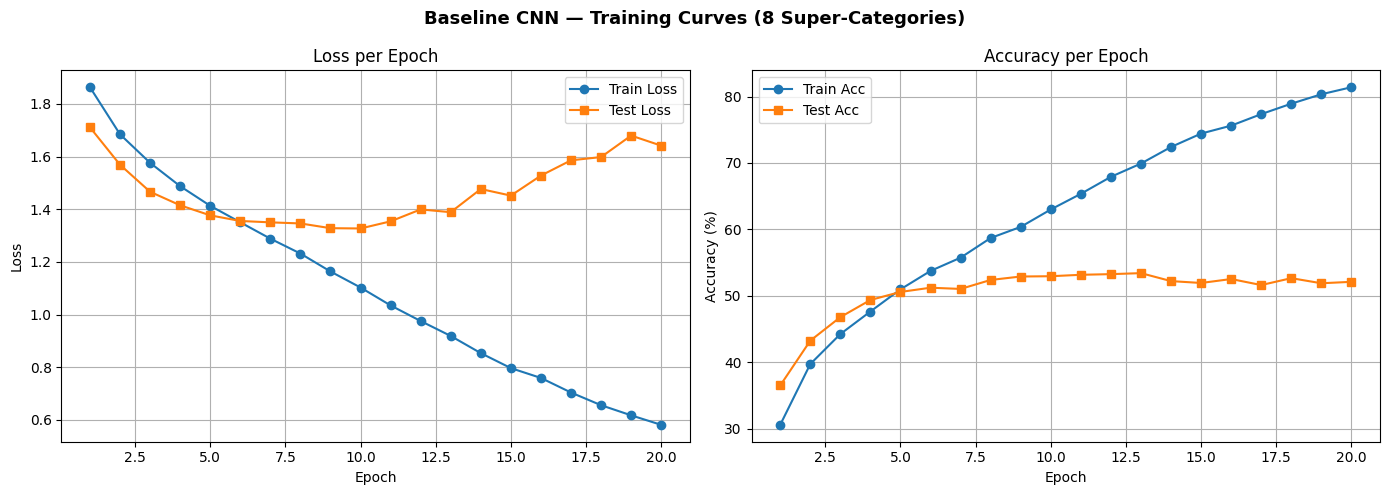

Saved → baseline_training_curves.png


In [ ]:
#12. Training Curves Plot
epochs_range = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Baseline CNN — Training Curves (8 Super-Categories)",
             fontsize=13, fontweight="bold")

axes[0].plot(epochs_range, train_losses, label="Train Loss", marker="o")
axes[0].plot(epochs_range, test_losses,  label="Test Loss",  marker="s")
axes[0].set_title("Loss per Epoch")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True)

axes[1].plot(epochs_range, train_accs, label="Train Acc", marker="o")
axes[1].plot(epochs_range, test_accs,  label="Test Acc",  marker="s")
axes[1].set_title("Accuracy per Epoch")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig("baseline_training_curves.png", dpi=150)
plt.show()
print("Saved → baseline_training_curves.png")

In [ ]:
#13. Detailed Evaluation
print("\nRunning full evaluation on test set...")
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print("\nClassification Report:")
print(classification_report(all_labels, all_preds,
                             target_names=SUPER_CATEGORY_NAMES,
                             zero_division=0))

final_acc = 100.0 * (all_preds == all_labels).sum() / len(all_labels)
print(f"Overall Test Accuracy: {final_acc:.2f}%")





Running full evaluation on test set...

Classification Report:
                       precision    recall  f1-score   support

      Pies & Pastries       0.44      0.35      0.39      1000
     Cakes & Desserts       0.52      0.45      0.48      1250
       Meat & Seafood       0.50      0.63      0.56      1500
   Fast Food & Snacks       0.44      0.53      0.48      1250
Noodles, Rice & Bread       0.46      0.43      0.44      1250
        Soups & Stews       0.66      0.70      0.68      1000
  Salads & Vegetables       0.72      0.70      0.71      1000
     Breakfast & Eggs       0.46      0.36      0.40      1000

             accuracy                           0.52      9250
            macro avg       0.53      0.52      0.52      9250
         weighted avg       0.52      0.52      0.52      9250

Overall Test Accuracy: 52.10%


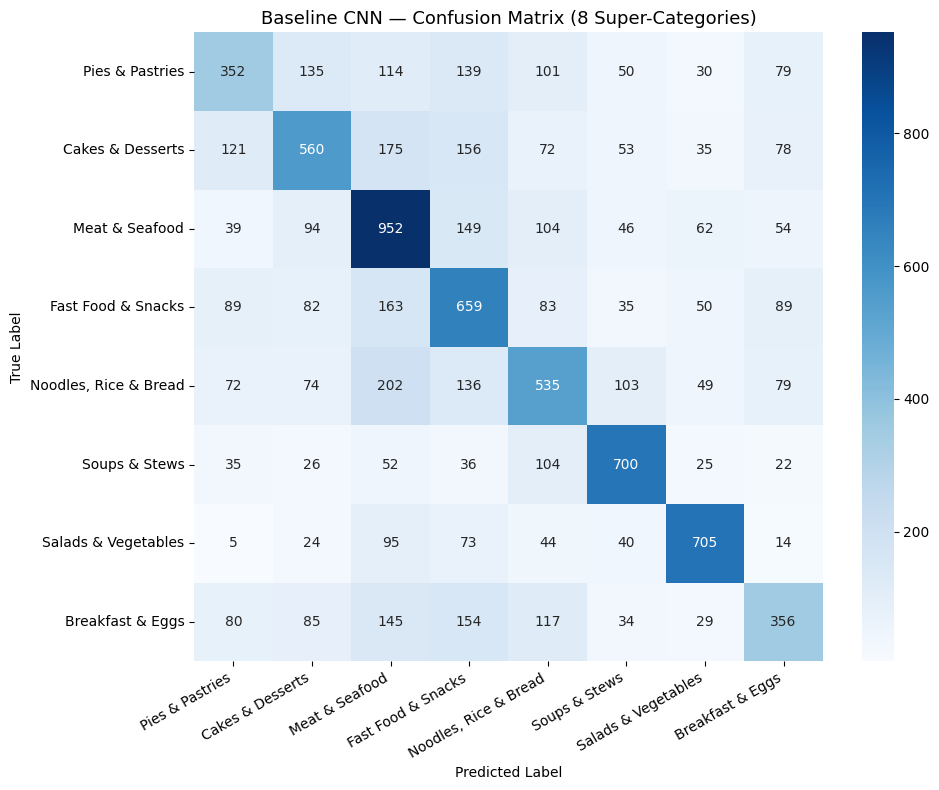

Saved → baseline_confusion_matrix.png


In [ ]:
# 14. Confusion Matrix 
cm = confusion_matrix(all_labels, all_preds, labels=list(range(NUM_CLASSES)))

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=SUPER_CATEGORY_NAMES,
            yticklabels=SUPER_CATEGORY_NAMES)
plt.title("Baseline CNN — Confusion Matrix (8 Super-Categories)", fontsize=13)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("baseline_confusion_matrix.png", dpi=150)
plt.show()
print("Saved → baseline_confusion_matrix.png")




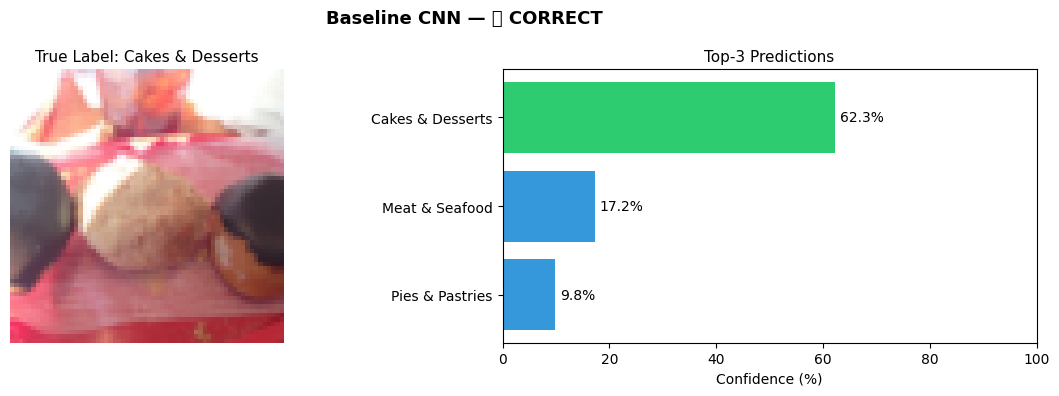

In [ ]:
# Test on a random training image
import random

model.eval()
rand_idx = random.randint(0, len(train_dataset) - 1)
image_tensor, true_label = train_dataset[rand_idx]

# Denormalize for display
mean = torch.tensor([0.485, 0.456, 0.406])
std  = torch.tensor([0.229, 0.224, 0.225])
img_display = image_tensor * std[:, None, None] + mean[:, None, None]
img_display = img_display.permute(1, 2, 0).clamp(0, 1).numpy()

with torch.no_grad():
    outputs = model(image_tensor.unsqueeze(0).to(device))
    probs   = torch.softmax(outputs, dim=1)[0]
    top3    = probs.topk(3)

top3_names  = [SUPER_CATEGORY_NAMES[i] for i in top3.indices.cpu().numpy()]
top3_scores = top3.values.cpu().numpy() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(img_display)
axes[0].axis("off")
axes[0].set_title(f"True Label: {SUPER_CATEGORY_NAMES[true_label]}", fontsize=11)

colors = ["#2ecc71" if top3.indices[0].item() == true_label else "#e74c3c"] + ["#3498db"] * 2
axes[1].barh(top3_names[::-1], top3_scores[::-1], color=colors[::-1])
axes[1].set_xlim(0, 100)
axes[1].set_xlabel("Confidence (%)")
axes[1].set_title("Top-3 Predictions", fontsize=11)
for j, (name, score) in enumerate(zip(top3_names[::-1], top3_scores[::-1])):
    axes[1].text(score + 1, j, f"{score:.1f}%", va="center", fontsize=10)

result = "CORRECT" if top3.indices[0].item() == true_label else f"WRONG (true: {SUPER_CATEGORY_NAMES[true_label]})"
plt.suptitle(f"Baseline CNN — {result}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Upload a food image to classify:


Saving caeser salad.jfif to caeser salad.jfif


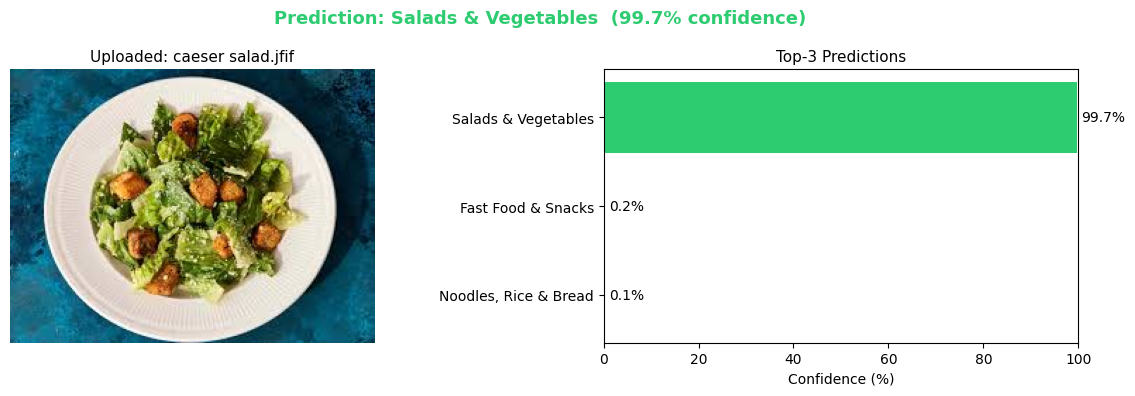


Top-3 Predictions for 'caeser salad.jfif':
  1. Salads & Vegetables       99.65%
  2. Fast Food & Snacks        0.20%
  3. Noodles, Rice & Bread     0.13%


In [44]:

from google.colab import files
from PIL import Image
import io

print("Upload a food image to classify:")
uploaded = files.upload()  # opens Colab file picker

for filename, file_bytes in uploaded.items():
    # Load and preprocess the image
    img = Image.open(io.BytesIO(file_bytes)).convert("RGB")

    preprocess = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])
    input_tensor = preprocess(img).unsqueeze(0).to(device)  # add batch dim

    # Run inference
    model.eval()
    with torch.no_grad():
        outputs = model(input_tensor)
        probs   = torch.softmax(outputs, dim=1)[0]
        top3    = probs.topk(3)

    # Display image + results
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Left: uploaded image
    axes[0].imshow(img)
    axes[0].axis("off")
    axes[0].set_title(f"Uploaded: {filename}", fontsize=11)

    # Right: bar chart of top-3 predictions
    top3_names  = [SUPER_CATEGORY_NAMES[i] for i in top3.indices.cpu().numpy()]
    top3_scores = top3.values.cpu().numpy() * 100

    colors = ["#2ecc71" if i == 0 else "#3498db" for i in range(3)]
    axes[1].barh(top3_names[::-1], top3_scores[::-1], color=colors[::-1])
    axes[1].set_xlim(0, 100)
    axes[1].set_xlabel("Confidence (%)")
    axes[1].set_title("Top-3 Predictions", fontsize=11)
    for j, (name, score) in enumerate(zip(top3_names[::-1], top3_scores[::-1])):
        axes[1].text(score + 1, j, f"{score:.1f}%", va="center", fontsize=10)

    plt.suptitle(
        f"Prediction: {top3_names[0]}  ({top3_scores[0]:.1f}% confidence)",
        fontsize=13, fontweight="bold", color="#2ecc71"
    )
    plt.tight_layout()
    plt.show()

    print(f"\nTop-3 Predictions for '{filename}':")
    for i, (name, score) in enumerate(zip(top3_names, top3_scores), 1):
        print(f"  {i}. {name:<25} {score:.2f}%")